# Financial Analysis Dashboard — Complete Jupyter Notebook

**Objective:** Perform a complete end-to-end financial transaction analysis using customer and transaction data.

### Analysis coverage
- Data loading and profiling
- Data cleaning and validation
- Customer + transaction integration
- Feature engineering
- KPI analysis
- Transaction analysis
- Channel analysis
- Customer segment analysis
- Risk analysis
- Fraud analysis
- Merchant/category analysis
- Geographic analysis
- Time-series analysis
- Outlier analysis
- Business insights
- Dashboard-ready summary tables
- Export of **one final cleaned dataset only**

> **Output file:** `financial_analysis_cleaned.csv`


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_PATH = r"C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis"

CUSTOMERS_FILE = os.path.join(PROJECT_PATH, "customers.csv")
TRANSACTIONS_FILE = os.path.join(PROJECT_PATH, "finance_transactions.csv")

OUTPUT_FILE = os.path.join(PROJECT_PATH, "financial_analysis_cleaned.csv")

print("Project path:", PROJECT_PATH)
print("Customers file:", CUSTOMERS_FILE)
print("Transactions file:", TRANSACTIONS_FILE)
print("Output file:", OUTPUT_FILE)


Project path: C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis
Customers file: C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis\customers.csv
Transactions file: C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis\finance_transactions.csv
Output file: C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis\financial_analysis_cleaned.csv


## 2. Load the datasets

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================

customers = pd.read_csv(CUSTOMERS_FILE)
transactions = pd.read_csv(TRANSACTIONS_FILE)

print("Customers shape:", customers.shape)
print("Transactions shape:", transactions.shape)

display(customers.head())
display(transactions.head())


Customers shape: (5000, 11)
Transactions shape: (50069, 15)


,customer_id,fisrt_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date
0,C00001,Karan,Chopra,Male,9/10/1982,Kolkata,West Bengal,Retired,SME,"₹988,416.79",15-04-2021
1,C00002,Ishaan,Patel,Male,7/10/1983,Chandigarh,Chandigarh,Salaried,Premium,"₹457,149.28",6/4/2022
2,C00003,Krishna,Patel,Male,27-11-1989,Hyderabad,Telangana,Retired,Retail,"₹378,907.24",6/3/2026
3,C00004,Amit,Verma,Male,13-08-1970,Lucknow,Uttar Pradesh,Salaried,Retail,"₹299,085.16",16-07-2021
4,C00005,Reyansh,Jain,Female,7/2/1977,Ahmedabad,Gujarat,Freelancer,SME,"₹775,436.07",23-02-2023


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no
0,T00000001,21-02-2025,A001795,C00629,Investment,Mobile App,Food Delivery,"24,721.24",123.61,22.25,INR,Success,No,63,REF8835851139
1,T00000002,28-01-2023,A004859,C02038,Transfer,UPI,Groceries,"18,711.77",93.56,16.84,INR,Success,No,21,REF9409811139
2,T00000003,25-06-2024,A003081,C00652,Transfer,Net Banking,Groceries,"45,865.90",0.00,0.00,INR,Success,No,25,REF1704628312
3,T00000004,20-02-2025,A004122,C01357,Withdrawal,Auto Debit,Salary,"4,310.91",NaN,0.78,INR,Failed,No,43,REF3937614748
4,T00000005,08-06-2024,A004150,C02547,Deposit,Branch,Shopping,"11,646.45",0.00,0.00,INR,Success,No,5,REF5855288886


## 3. Initial data profiling

In [3]:
# ============================================================
# 3. INITIAL PROFILING
# ============================================================

print("CUSTOMERS")
print("=" * 70)
display(customers.info())
display(customers.describe(include="all").T)

print("\nTRANSACTIONS")
print("=" * 70)
display(transactions.info())
display(transactions.describe(include="all").T)

print("\nMissing values - Customers")
display(customers.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nMissing values - Transactions")
display(transactions.isna().sum().sort_values(ascending=False).to_frame("missing"))


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       5000 non-null   str  
 1   fisrt_name        5000 non-null   str  
 2   second_name       5000 non-null   str  
 3   gender            5000 non-null   str  
 4   date_of_birth     5000 non-null   str  
 5   city              5000 non-null   str  
 6   state             5000 non-null   str  
 7   occupation        5000 non-null   str  
 8   customer_segment  5000 non-null   str  
 9   annual_income     5000 non-null   str  
 10  join_date         5000 non-null   str  
dtypes: str(11)
memory usage: 849.1 KB


None

,count,unique,top,freq
customer_id,5000,5000,C00001,1
fisrt_name,5000,30,Aditya,188
second_name,5000,20,Kapoor,273
gender,5000,2,Female,2544
date_of_birth,5000,4264,12/2/2004,4
city,5000,20,Gurugram,286
state,5000,13,Maharashtra,747
occupation,5000,6,Retired,855
customer_segment,5000,5,Retail,2703
annual_income,5000,4733,"₹180,000.00",146



TRANSACTIONS
<class 'pandas.DataFrame'>
RangeIndex: 50069 entries, 0 to 50068
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      50069 non-null  str    
 1   transaction_date    50069 non-null  str    
 2   account_id          50069 non-null  str    
 3   customer_id         50069 non-null  str    
 4   transaction_type    50069 non-null  str    
 5   channel             50069 non-null  str    
 6   merchant_category   50069 non-null  str    
 7   amount              50069 non-null  float64
 8   fee_amount          50045 non-null  float64
 9   tax_amount          50069 non-null  float64
 10  currency            50069 non-null  str    
 11  transaction_status  50069 non-null  str    
 12  is_fraud            50069 non-null  str    
 13  risk_score          50069 non-null  int64  
 14  reference_no        50069 non-null  str    
dtypes: float64(3), int64(1), str(11)
memory usage: 9.6

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,50069,50000,T00000009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,50069,1216,27-09-2023,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_id,50069,7987,A007778,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,50069,3983,C04756,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,50069,10,Loan EMI,9140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,50069,13,Branch,7236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,50069,14,Rent,3708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,"50,069.00",NaN,NaN,NaN,"9,110.26","12,338.16","-21,449.31","2,371.85","5,002.79","11,229.06","312,586.25"
fee_amount,"50,045.00",NaN,NaN,NaN,14.53,34.24,0.00,0.00,2.79,14.66,947.35
tax_amount,"50,069.00",NaN,NaN,NaN,2.62,6.16,0.00,0.00,0.50,2.64,170.52



Missing values - Customers


,missing
customer_id,0
fisrt_name,0
second_name,0
gender,0
date_of_birth,0
city,0
state,0
occupation,0
customer_segment,0
annual_income,0



Missing values - Transactions


,missing
fee_amount,24
transaction_date,0
transaction_id,0
customer_id,0
transaction_type,0
channel,0
account_id,0
merchant_category,0
amount,0
tax_amount,0


## 4. Standardize column names and known data issues

In [4]:
# ============================================================
# 4. STANDARDIZE COLUMN NAMES & KNOWN ISSUES
# ============================================================

def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df

customers = clean_column_names(customers)
transactions = clean_column_names(transactions)

# Known source typo
if "fisrt_name" in customers.columns and "first_name" not in customers.columns:
    customers.rename(columns={"fisrt_name": "first_name"}, inplace=True)

# Standardize text values
for df in [customers, transactions]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype("string").str.strip()

# Known source typo
if "channel" in transactions.columns:
    transactions["channel"] = transactions["channel"].replace({
        "M@bile App": "Mobile App"
    })

print("Customer columns:")
print(customers.columns.tolist())

print("\nTransaction columns:")
print(transactions.columns.tolist())


Customer columns:
['customer_id', 'first_name', 'second_name', 'gender', 'date_of_birth', 'city', 'state', 'occupation', 'customer_segment', 'annual_income', 'join_date']

Transaction columns:
['transaction_id', 'transaction_date', 'account_id', 'customer_id', 'transaction_type', 'channel', 'merchant_category', 'amount', 'fee_amount', 'tax_amount', 'currency', 'transaction_status', 'is_fraud', 'risk_score', 'reference_no']


## 5. Clean numeric columns

In [5]:
# ============================================================
# 5. CLEAN NUMERIC COLUMNS
# ============================================================

def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("₹", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("€", "", regex=False)
        .str.replace("£", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

numeric_candidates = [
    "amount", "fee", "fees", "tax", "taxes",
    "risk_score", "income", "annual_income",
    "credit_limit", "balance"
]

for col in numeric_candidates:
    if col in transactions.columns:
        transactions[col] = clean_numeric_series(transactions[col])
    if col in customers.columns:
        customers[col] = clean_numeric_series(customers[col])

print("Numeric cleaning completed.")


Numeric cleaning completed.


## 6. Parse dates

In [6]:
# ============================================================
# 6. DATE CLEANING
# ============================================================

date_columns = []

for col in transactions.columns:
    if any(word in col for word in ["date", "time", "timestamp"]):
        date_columns.append(col)

for col in date_columns:
    transactions[col] = pd.to_datetime(
        transactions[col],
        format="mixed",
        dayfirst=True,
        errors="coerce"
    )

print("Date columns detected:", date_columns)

for col in date_columns:
    print(f"{col}: {transactions[col].min()} -> {transactions[col].max()}")


Date columns detected: ['transaction_date']
transaction_date: 2023-01-01 00:00:00 -> 2026-12-04 00:00:00


## 7. Duplicate and data-quality checks

In [7]:
# ============================================================
# 7. DATA QUALITY CHECKS
# ============================================================

exact_duplicate_rows = transactions.duplicated().sum()

print("Exact duplicate transaction rows:", exact_duplicate_rows)

if "transaction_id" in transactions.columns:
    duplicate_transaction_ids = transactions[
        transactions["transaction_id"].duplicated(keep=False)
    ].sort_values("transaction_id")
    print("Duplicate transaction IDs:", transactions["transaction_id"].duplicated().sum())
    display(duplicate_transaction_ids.head(20))
else:
    duplicate_transaction_ids = pd.DataFrame()

# Remove only exact duplicate rows
transactions = transactions.drop_duplicates().reset_index(drop=True)

print("Transaction rows after removing exact duplicates:", len(transactions))

if "fee" in transactions.columns:
    print("Missing fees:", transactions["fee"].isna().sum())

if "amount" in transactions.columns:
    print("Negative amounts:", (transactions["amount"] < 0).sum())

if "risk_score" in transactions.columns:
    print("Risk scores outside 0-100:",
          ((transactions["risk_score"] < 0) | (transactions["risk_score"] > 100)).sum())


Exact duplicate transaction rows: 68
Duplicate transaction IDs: 69


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no
8,T00000009,2024-09-24,A006977,C01463,Transfer,ATM,Rent,"4,237.33",NaN,3.81,INR,Success,No,17,REF7746654436
9,T00000009,2024-09-24,A006977,C01463,Transfer,ATM,Rent,"4,237.33",21.19,3.81,INR,Success,No,17,REF7746654436
14,T00000014,2024-10-08,A004138,C00960,Loan EMI,UPI,Travel,"9,334.16",9.33,1.68,INR,Success,No,45,REF9776706632
15,T00000014,2024-10-08,A004138,C00960,Loan EMI,UPI,Travel,"9,334.16",9.33,1.68,INR,Success,No,45,REF9776706632
66,T00000065,2023-02-26,A006060,C00103,Deposit,Net Banking,Shopping,"6,526.38",0.00,0.00,INR,Success,No,5,REF3244794918
67,T00000065,2023-02-26,A006060,C00103,Deposit,Net Banking,Shopping,"6,526.38",0.00,0.00,INR,Success,No,5,REF3244794918
138,T00000136,2026-03-18,A003806,C03104,Transfer,Net Banking,Salary,"10,693.90",10.69,1.92,INR,Success,No,19,REF1743695851
139,T00000136,2026-03-18,A003806,C03104,Transfer,Net Banking,Salary,"10,693.90",10.69,1.92,INR,Success,No,19,REF1743695851
49840,T00049837,2025-03-17,A001779,C01671,Refund,POS,Bank Charges,"2,984.80",2.98,0.54,INR,Success,No,62,REF1564322819
50022,T00049837,2025-03-17,A001779,C01671,Refund,POS,Bank Charges,"2,984.80",2.98,0.54,INR,Success,No,62,REF1564322819


Transaction rows after removing exact duplicates: 50001
Negative amounts: 8
Risk scores outside 0-100: 0


## 8. Customer and transaction key validation

In [8]:
# ============================================================
# 8. KEY VALIDATION
# ============================================================

if "customer_id" in customers.columns and "customer_id" in transactions.columns:
    customer_ids = set(customers["customer_id"].dropna().astype(str))
    transaction_customer_ids = set(transactions["customer_id"].dropna().astype(str))

    orphan_ids = transaction_customer_ids - customer_ids

    print("Unique customers:", customers["customer_id"].nunique())
    print("Unique transaction customer IDs:", transactions["customer_id"].nunique())
    print("Orphan customer IDs:", len(orphan_ids))
    print("Duplicate customer IDs:", customers["customer_id"].duplicated().sum())

    if len(orphan_ids) > 0:
        print("Sample orphan IDs:", list(orphan_ids)[:10])


Unique customers: 5000
Unique transaction customer IDs: 3983
Orphan customer IDs: 0
Duplicate customer IDs: 0


## 9. Merge customer and transaction data

In [9]:
# ============================================================
# 9. MERGE DATASETS
# ============================================================

financial_analysis = transactions.merge(
    customers,
    on="customer_id",
    how="left",
    suffixes=("", "_customer")
)

print("Integrated dataset shape:", financial_analysis.shape)

missing_customer_matches = financial_analysis["customer_id"].isna().sum()

print("Rows without customer match:", missing_customer_matches)
display(financial_analysis.head())


Integrated dataset shape: (50001, 25)
Rows without customer match: 0


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no,first_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date
0,T00000001,2025-02-21,A001795,C00629,Investment,Mobile App,Food Delivery,"24,721.24",123.61,22.25,INR,Success,No,63,REF8835851139,Neha,Desai,Female,16-07-1994,Coimbatore,Tamil Nadu,Salaried,Premium,"1,521,243.86",28-03-2025
1,T00000002,2023-01-28,A004859,C02038,Transfer,UPI,Groceries,"18,711.77",93.56,16.84,INR,Success,No,21,REF9409811139,Aarav,Chopra,Female,18-12-1989,Bengaluru,Karnataka,Freelancer,Retail,"365,023.04",15-01-2021
2,T00000003,2024-06-25,A003081,C00652,Transfer,Net Banking,Groceries,"45,865.90",0.00,0.00,INR,Success,No,25,REF1704628312,Sneha,Verma,Male,24-06-1988,Chandigarh,Chandigarh,Retired,Wealth,"1,973,706.42",2/10/2024
3,T00000004,2025-02-20,A004122,C01357,Withdrawal,Auto Debit,Salary,"4,310.91",NaN,0.78,INR,Failed,No,43,REF3937614748,Pooja,Reddy,Male,24-09-2002,Pune,Maharashtra,Self Employed,Corporate,"555,476.53",15-03-2020
4,T00000005,2024-06-08,A004150,C02547,Deposit,Branch,Shopping,"11,646.45",0.00,0.00,INR,Success,No,5,REF5855288886,Reyansh,Chopra,Female,22-09-2004,Mysuru,Karnataka,Self Employed,SME,"1,107,795.82",25-09-2023


## 10. Feature engineering

In [10]:
# ============================================================
# 10. FEATURE ENGINEERING
# ============================================================

# Identify transaction date
transaction_date_col = None
for candidate in ["transaction_date", "date", "transaction_datetime", "datetime"]:
    if candidate in financial_analysis.columns:
        transaction_date_col = candidate
        break

if transaction_date_col:
    financial_analysis["transaction_year"] = financial_analysis[transaction_date_col].dt.year
    financial_analysis["transaction_month"] = financial_analysis[transaction_date_col].dt.month
    financial_analysis["transaction_month_name"] = financial_analysis[transaction_date_col].dt.month_name()
    financial_analysis["transaction_quarter"] = financial_analysis[transaction_date_col].dt.to_period("Q").astype(str)

# Age and age group
if "date_of_birth" in financial_analysis.columns and transaction_date_col:
    dob = pd.to_datetime(financial_analysis["date_of_birth"], errors="coerce")
    financial_analysis["age"] = (
        financial_analysis[transaction_date_col].dt.year - dob.dt.year
        - (
            (financial_analysis[transaction_date_col].dt.month < dob.dt.month)
            | (
                (financial_analysis[transaction_date_col].dt.month == dob.dt.month)
                & (financial_analysis[transaction_date_col].dt.day < dob.dt.day)
            )
        ).astype(int)
    )
elif "age" in financial_analysis.columns:
    financial_analysis["age"] = pd.to_numeric(financial_analysis["age"], errors="coerce")

if "age" in financial_analysis.columns:
    financial_analysis["age_group"] = pd.cut(
        financial_analysis["age"],
        bins=[0, 18, 25, 35, 45, 55, 65, 120],
        labels=["<=18", "19-25", "26-35", "36-45", "46-55", "56-65", "66+"],
        include_lowest=True
    )

# Amount-based features
if "amount" in financial_analysis.columns:
    financial_analysis["transaction_value"] = financial_analysis["amount"]
    financial_analysis["success_flag"] = (
        financial_analysis.get("transaction_status", "").astype("string").str.lower().eq("success")
    ).astype(int) if "transaction_status" in financial_analysis.columns else np.nan

# Charges
fee_col = "fee" if "fee" in financial_analysis.columns else ("fees" if "fees" in financial_analysis.columns else None)
tax_col = "tax" if "tax" in financial_analysis.columns else ("taxes" if "taxes" in financial_analysis.columns else None)

if fee_col:
    financial_analysis["fee_clean"] = financial_analysis[fee_col].fillna(0)
else:
    financial_analysis["fee_clean"] = 0

if tax_col:
    financial_analysis["tax_clean"] = financial_analysis[tax_col].fillna(0)
else:
    financial_analysis["tax_clean"] = 0

financial_analysis["total_charges"] = financial_analysis["fee_clean"] + financial_analysis["tax_clean"]

if "amount" in financial_analysis.columns:
    financial_analysis["net_transaction_value"] = financial_analysis["amount"] - financial_analysis["total_charges"]

# Risk category
if "risk_score" in financial_analysis.columns:
    financial_analysis["risk_category"] = pd.cut(
        financial_analysis["risk_score"],
        bins=[-np.inf, 25, 50, 75, np.inf],
        labels=["Low", "Medium", "High", "Very High"]
    )

# Income segment
income_col = None
for candidate in ["income", "annual_income"]:
    if candidate in financial_analysis.columns:
        income_col = candidate
        break

if income_col:
    financial_analysis["income_segment"] = pd.qcut(
        financial_analysis[income_col],
        q=4,
        labels=["Low Income", "Lower-Middle Income", "Upper-Middle Income", "High Income"],
        duplicates="drop"
    )

# Fraud flag standardization
fraud_col = None
for candidate in ["fraud_flag", "is_fraud", "fraud"]:
    if candidate in financial_analysis.columns:
        fraud_col = candidate
        break

if fraud_col:
    financial_analysis["fraud_flag_clean"] = (
        financial_analysis[fraud_col]
        .astype("string")
        .str.lower()
        .isin(["1", "true", "yes", "y", "fraud"])
    )
else:
    financial_analysis["fraud_flag_clean"] = False

# Simple IQR outlier flag
if "amount" in financial_analysis.columns:
    q1 = financial_analysis["amount"].quantile(0.25)
    q3 = financial_analysis["amount"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    financial_analysis["amount_outlier_flag"] = (
        (financial_analysis["amount"] < lower_bound) |
        (financial_analysis["amount"] > upper_bound)
    )

print("Feature engineering completed.")
display(financial_analysis.head())


Feature engineering completed.


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no,first_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date,transaction_year,transaction_month,transaction_month_name,transaction_quarter,age,age_group,transaction_value,success_flag,fee_clean,tax_clean,total_charges,net_transaction_value,risk_category,income_segment,fraud_flag_clean,amount_outlier_flag
0,T00000001,2025-02-21,A001795,C00629,Investment,Mobile App,Food Delivery,"24,721.24",123.61,22.25,INR,Success,No,63,REF8835851139,Neha,Desai,Female,16-07-1994,Coimbatore,Tamil Nadu,Salaried,Premium,"1,521,243.86",28-03-2025,2025,2,February,2025Q1,30.00,26-35,"24,721.24",1,0,0,0,"24,721.24",High,High Income,False,True
1,T00000002,2023-01-28,A004859,C02038,Transfer,UPI,Groceries,"18,711.77",93.56,16.84,INR,Success,No,21,REF9409811139,Aarav,Chopra,Female,18-12-1989,Bengaluru,Karnataka,Freelancer,Retail,"365,023.04",15-01-2021,2023,1,January,2023Q1,33.00,26-35,"18,711.77",1,0,0,0,"18,711.77",Low,Low Income,False,False
2,T00000003,2024-06-25,A003081,C00652,Transfer,Net Banking,Groceries,"45,865.90",0.00,0.00,INR,Success,No,25,REF1704628312,Sneha,Verma,Male,24-06-1988,Chandigarh,Chandigarh,Retired,Wealth,"1,973,706.42",2/10/2024,2024,6,June,2024Q2,36.00,36-45,"45,865.90",1,0,0,0,"45,865.90",Low,High Income,False,True
3,T00000004,2025-02-20,A004122,C01357,Withdrawal,Auto Debit,Salary,"4,310.91",NaN,0.78,INR,Failed,No,43,REF3937614748,Pooja,Reddy,Male,24-09-2002,Pune,Maharashtra,Self Employed,Corporate,"555,476.53",15-03-2020,2025,2,February,2025Q1,22.00,19-25,"4,310.91",0,0,0,0,"4,310.91",Medium,Lower-Middle Income,False,False
4,T00000005,2024-06-08,A004150,C02547,Deposit,Branch,Shopping,"11,646.45",0.00,0.00,INR,Success,No,5,REF5855288886,Reyansh,Chopra,Female,22-09-2004,Mysuru,Karnataka,Self Employed,SME,"1,107,795.82",25-09-2023,2024,6,June,2024Q2,19.00,19-25,"11,646.45",1,0,0,0,"11,646.45",Low,High Income,False,False


## 11. Final data-quality report

In [11]:
# ============================================================
# 11. FINAL DATA QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "metric": [
        "Customers",
        "Transactions after exact duplicate removal",
        "Integrated rows",
        "Missing values",
        "Duplicate rows",
        "Duplicate transaction IDs",
        "Orphan customer IDs",
        "Negative amounts",
        "Missing fees"
    ],
    "value": [
        customers["customer_id"].nunique() if "customer_id" in customers.columns else len(customers),
        len(transactions),
        len(financial_analysis),
        int(financial_analysis.isna().sum().sum()),
        exact_duplicate_rows,
        int(transactions["transaction_id"].duplicated().sum()) if "transaction_id" in transactions.columns else np.nan,
        len(orphan_ids) if "orphan_ids" in globals() else np.nan,
        int((transactions["amount"] < 0).sum()) if "amount" in transactions.columns else np.nan,
        int(transactions[fee_col].isna().sum()) if fee_col and fee_col in transactions.columns else np.nan
    ]
})

display(quality_report)


,metric,value
0,Customers,"5,000.00"
1,Transactions after exact duplicate removal,"50,001.00"
2,Integrated rows,"50,001.00"
3,Missing values,"43,246.00"
4,Duplicate rows,68.00
5,Duplicate transaction IDs,1.00
6,Orphan customer IDs,0.00
7,Negative amounts,8.00
8,Missing fees,NaN


## 12. Executive KPI analysis

In [12]:
# ============================================================
# 12. EXECUTIVE KPIs
# ============================================================

total_customers = financial_analysis["customer_id"].nunique() if "customer_id" in financial_analysis.columns else np.nan
total_transactions = len(financial_analysis)

total_value = financial_analysis["amount"].sum() if "amount" in financial_analysis.columns else np.nan
average_transaction_value = financial_analysis["amount"].mean() if "amount" in financial_analysis.columns else np.nan

success_rate = (
    financial_analysis["success_flag"].mean() * 100
    if "success_flag" in financial_analysis.columns and financial_analysis["success_flag"].notna().any()
    else np.nan
)

fraud_transactions = financial_analysis["fraud_flag_clean"].sum()
fraud_amount = (
    financial_analysis.loc[financial_analysis["fraud_flag_clean"], "amount"].sum()
    if "amount" in financial_analysis.columns else np.nan
)

average_risk_score = (
    financial_analysis["risk_score"].mean()
    if "risk_score" in financial_analysis.columns else np.nan
)

total_fees = financial_analysis["fee_clean"].sum()
total_taxes = financial_analysis["tax_clean"].sum()
total_charges = financial_analysis["total_charges"].sum()

kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Transactions",
        "Total Transaction Value",
        "Average Transaction Value",
        "Success Rate",
        "Total Fees",
        "Total Taxes",
        "Total Charges",
        "Fraud Transactions",
        "Fraud Amount",
        "Average Risk Score"
    ],
    "Value": [
        total_customers,
        total_transactions,
        total_value,
        average_transaction_value,
        success_rate,
        total_fees,
        total_taxes,
        total_charges,
        fraud_transactions,
        fraud_amount,
        average_risk_score
    ]
})

display(kpis)


,KPI,Value
0,Total Customers,"3,983.00"
1,Total Transactions,"50,001.00"
2,Total Transaction Value,"455,395,378.49"
3,Average Transaction Value,"9,107.73"
4,Success Rate,85.74
5,Total Fees,0.00
6,Total Taxes,0.00
7,Total Charges,0.00
8,Fraud Transactions,630.00
9,Fraud Amount,"5,969,443.52"


## 13. Transaction type analysis

,transaction_type,transactions,total_value,average_value,success_rate
6,Loan EMI,9127,"130,904,063.91","14,342.51",85.61
8,Transfer,8463,"120,582,275.62","14,248.17",86.06
2,Deposit,4957,"68,697,539.50","13,858.69",85.50
5,Investment,3565,"49,164,382.61","13,790.85",86.51
1,Card Payment,5324,"26,841,062.56","5,041.52",86.29
0,Bill Payment,4303,"21,743,247.88","5,053.04",85.15
9,Withdrawal,4277,"21,384,755.67","4,999.94",85.97
4,Interest Credit,4016,"9,156,309.71","2,279.96",85.06
7,Refund,2334,"5,174,306.52","2,216.93",85.60
3,Fee Charge,3635,"1,747,434.51",480.72,85.34


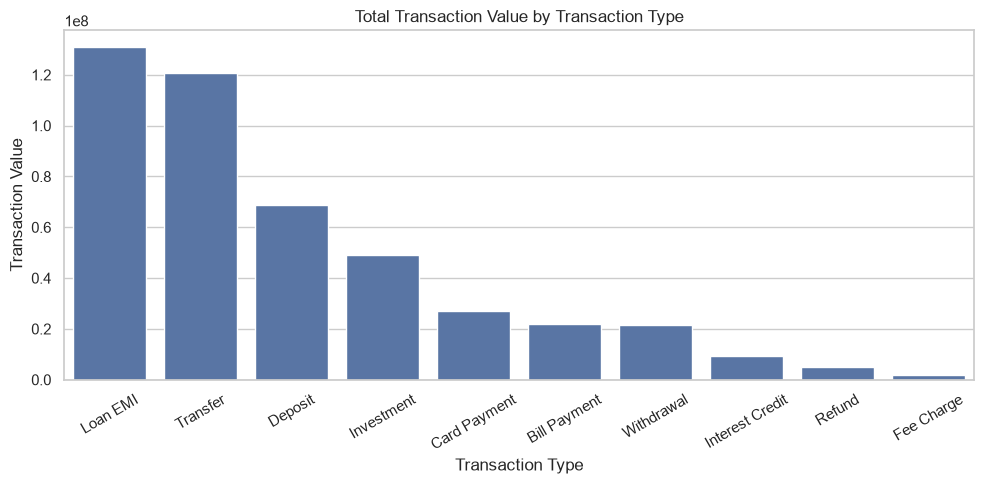

In [13]:
# ============================================================
# 13. TRANSACTION TYPE ANALYSIS
# ============================================================

if "transaction_type" in financial_analysis.columns:
    transaction_type_summary = (
        financial_analysis.groupby("transaction_type", dropna=False)
        .agg(
            transactions=("transaction_type", "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean"),
            success_rate=("success_flag", "mean")
        )
        .reset_index()
        .sort_values("total_value", ascending=False)
    )

    transaction_type_summary["success_rate"] *= 100
    display(transaction_type_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=transaction_type_summary,
        x="transaction_type",
        y="total_value"
    )
    plt.title("Total Transaction Value by Transaction Type")
    plt.xlabel("Transaction Type")
    plt.ylabel("Transaction Value")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 14. Channel performance

,channel,transactions,total_value,average_value,success_rate,fraud_transactions
6,UPI,7199,"66,012,714.14","9,169.71",85.68,86
2,Branch,7228,"65,613,535.04","9,077.69",85.87,93
0,ATM,7177,"65,188,215.68","9,082.93",85.08,101
3,Mobile App,7103,"65,092,968.43","9,164.15",85.67,86
5,POS,7110,"64,826,921.77","9,117.71",86.20,97
1,Auto Debit,7071,"64,527,365.07","9,125.63",85.08,77
4,Net Banking,7113,"64,133,658.36","9,016.40",86.59,90


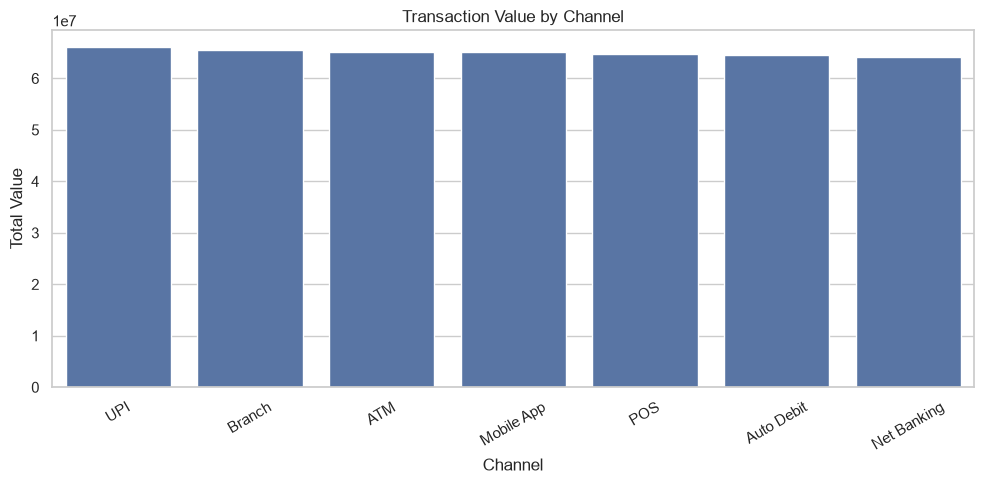

In [14]:
# ============================================================
# 14. CHANNEL ANALYSIS
# ============================================================

if "channel" in financial_analysis.columns:
    channel_summary = (
        financial_analysis.groupby("channel", dropna=False)
        .agg(
            transactions=("channel", "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean"),
            success_rate=("success_flag", "mean"),
            fraud_transactions=("fraud_flag_clean", "sum")
        )
        .reset_index()
        .sort_values("total_value", ascending=False)
    )

    channel_summary["success_rate"] *= 100
    display(channel_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=channel_summary, x="channel", y="total_value")
    plt.title("Transaction Value by Channel")
    plt.xlabel("Channel")
    plt.ylabel("Total Value")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 15. Customer segment analysis

,customer_segment,customers,transactions,total_value,average_transaction,success_rate
2,Retail,2177,27112,"248,005,884.12","9,147.46",85.59
1,Premium,711,9210,"84,309,434.14","9,154.12",85.78
3,SME,616,8003,"71,829,390.56","8,975.31",85.93
0,Corporate,284,3432,"30,827,154.58","8,982.27",85.75
4,Wealth,195,2244,"20,423,515.09","9,101.39",86.63


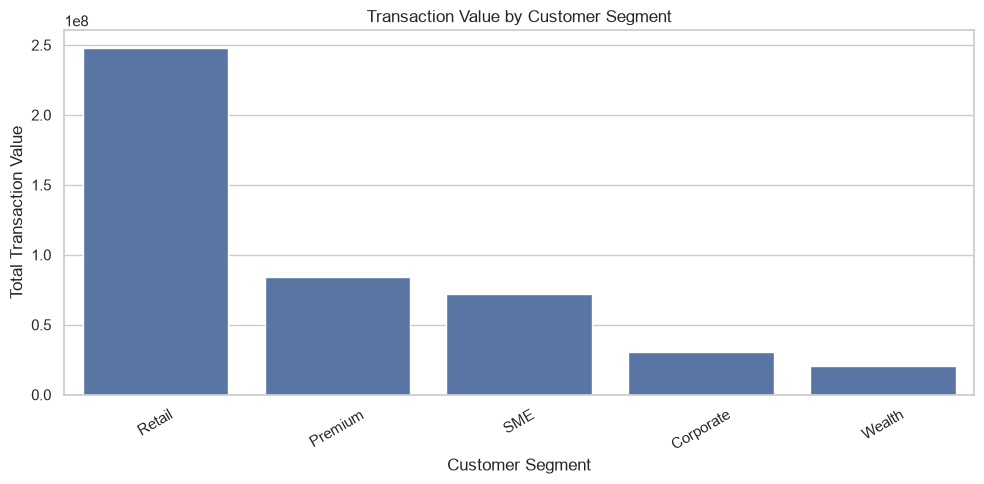

In [15]:
# ============================================================
# 15. CUSTOMER SEGMENT ANALYSIS
# ============================================================

segment_col = None
for candidate in ["customer_segment", "segment", "customer_type"]:
    if candidate in financial_analysis.columns:
        segment_col = candidate
        break

if segment_col:
    segment_summary = (
        financial_analysis.groupby(segment_col, dropna=False)
        .agg(
            customers=("customer_id", "nunique"),
            transactions=("customer_id", "size"),
            total_value=("amount", "sum"),
            average_transaction=("amount", "mean"),
            success_rate=("success_flag", "mean")
        )
        .reset_index()
        .sort_values("total_value", ascending=False)
    )

    segment_summary["success_rate"] *= 100
    display(segment_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=segment_summary, x=segment_col, y="total_value")
    plt.title("Transaction Value by Customer Segment")
    plt.xlabel("Customer Segment")
    plt.ylabel("Total Transaction Value")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 16. Risk analysis

,risk_category,transactions,total_value,average_value,average_risk_score,fraud_transactions,value_share_pct
0,Low,17586,"159,386,537.15","9,063.26",12.97,0,35.00
1,Medium,17734,"160,275,089.17","9,037.73",37.98,0,35.19
2,High,14239,"131,635,330.31","9,244.70",60.63,188,28.91
3,Very High,442,"4,098,421.86","9,272.45",88.61,442,0.90


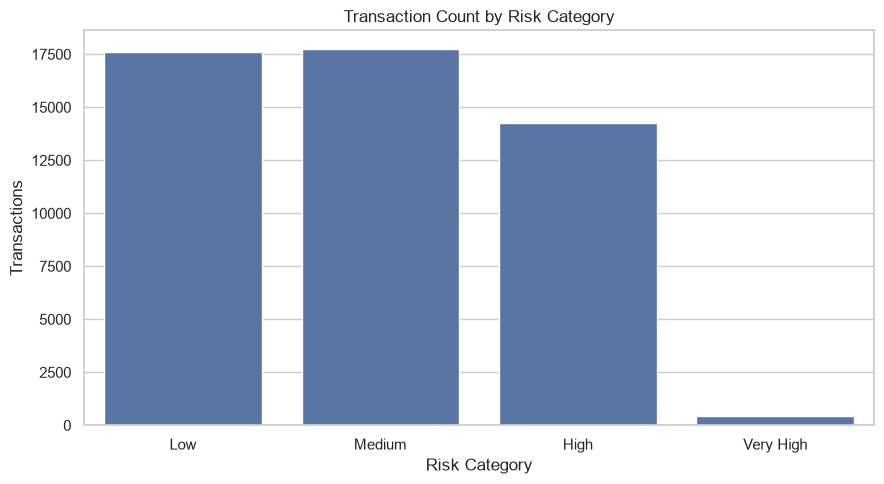

In [16]:
# ============================================================
# 16. RISK ANALYSIS
# ============================================================

if "risk_category" in financial_analysis.columns:
    risk_summary = (
        financial_analysis.groupby("risk_category", observed=False)
        .agg(
            transactions=("risk_category", "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean"),
            average_risk_score=("risk_score", "mean"),
            fraud_transactions=("fraud_flag_clean", "sum")
        )
        .reset_index()
    )

    risk_summary["value_share_pct"] = (
        risk_summary["total_value"] / risk_summary["total_value"].sum() * 100
    )

    display(risk_summary)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=risk_summary, x="risk_category", y="transactions")
    plt.title("Transaction Count by Risk Category")
    plt.xlabel("Risk Category")
    plt.ylabel("Transactions")
    plt.tight_layout()
    plt.show()


## 17. Fraud analysis

In [17]:
# ============================================================
# 17. FRAUD ANALYSIS
# ============================================================

fraud_summary = pd.DataFrame({
    "Metric": [
        "Fraud Transactions",
        "Fraud Transaction Value",
        "Fraud Rate %",
        "Average Fraud Transaction Value"
    ],
    "Value": [
        fraud_transactions,
        fraud_amount,
        fraud_transactions / total_transactions * 100 if total_transactions else np.nan,
        fraud_amount / fraud_transactions if fraud_transactions else np.nan
    ]
})

display(fraud_summary)

if "channel" in financial_analysis.columns:
    fraud_by_channel = (
        financial_analysis.groupby("channel")
        .agg(
            transactions=("channel", "size"),
            fraud_transactions=("fraud_flag_clean", "sum"),
            fraud_amount=("amount", lambda x: x[financial_analysis.loc[x.index, "fraud_flag_clean"]].sum())
        )
        .reset_index()
    )

    fraud_by_channel["fraud_rate_pct"] = (
        fraud_by_channel["fraud_transactions"] /
        fraud_by_channel["transactions"] * 100
    )

    display(fraud_by_channel.sort_values("fraud_rate_pct", ascending=False))


,Metric,Value
0,Fraud Transactions,630.00
1,Fraud Transaction Value,"5,969,443.52"
2,Fraud Rate %,1.26
3,Average Fraud Transaction Value,"9,475.31"


,channel,transactions,fraud_transactions,fraud_amount,fraud_rate_pct
0,ATM,7177,101,"1,168,054.24",1.41
5,POS,7110,97,"655,818.55",1.36
2,Branch,7228,93,"791,790.73",1.29
4,Net Banking,7113,90,"826,303.64",1.27
3,Mobile App,7103,86,"862,883.30",1.21
6,UPI,7199,86,"839,000.80",1.19
1,Auto Debit,7071,77,"825,592.26",1.09


## 18. Merchant/category analysis

,merchant_category,transactions,total_value,average_value,fraud_transactions
9,Rent,3706,"34,636,092.00","9,345.95",51
10,Salary,3647,"34,306,053.21","9,406.65",45
5,Groceries,3624,"33,853,027.31","9,341.34",43
11,Shopping,3613,"33,115,584.67","9,165.68",53
0,Bank Charges,3527,"33,015,765.16","9,360.86",39
2,Entertainment,3563,"32,971,662.63","9,253.90",49
3,Food Delivery,3615,"32,901,787.63","9,101.46",48
6,Healthcare,3597,"31,954,634.84","8,883.69",35
1,Education,3557,"31,913,558.87","8,972.04",38
7,Insurance,3623,"31,842,490.99","8,788.98",52


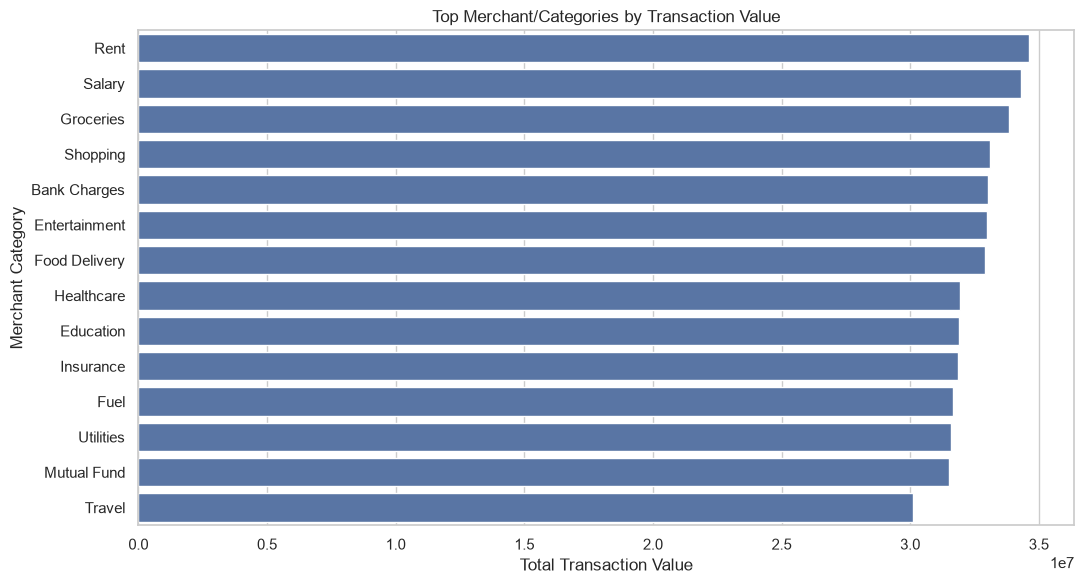

In [18]:
# ============================================================
# 18. MERCHANT / CATEGORY ANALYSIS
# ============================================================

category_col = None
for candidate in ["merchant_category", "category", "merchant_type"]:
    if candidate in financial_analysis.columns:
        category_col = candidate
        break

if category_col:
    category_summary = (
        financial_analysis.groupby(category_col, dropna=False)
        .agg(
            transactions=(category_col, "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean"),
            fraud_transactions=("fraud_flag_clean", "sum")
        )
        .reset_index()
        .sort_values("total_value", ascending=False)
    )

    display(category_summary)

    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=category_summary.head(15),
        y=category_col,
        x="total_value"
    )
    plt.title("Top Merchant/Categories by Transaction Value")
    plt.xlabel("Total Transaction Value")
    plt.ylabel(category_col.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


## 19. Geographic analysis

,state,customers,transactions,total_value,average_value,fraud_transactions
7,Maharashtra,583,7356,"68,266,471.75","9,280.38",90
4,Karnataka,438,5883,"52,858,322.32","8,984.93",88
2,Gujarat,436,5577,"50,061,741.93","8,976.46",62
9,Tamil Nadu,386,4885,"44,896,727.31","9,190.73",73
11,Uttar Pradesh,390,4723,"43,552,494.69","9,221.36",52
6,Madhya Pradesh,390,4651,"40,923,639.03","8,798.89",53
3,Haryana,228,2662,"25,629,276.57","9,627.83",30
5,Kerala,197,2656,"24,184,039.34","9,105.44",25
1,Delhi,205,2712,"23,455,435.05","8,648.76",39
12,West Bengal,189,2498,"22,204,010.82","8,888.72",28


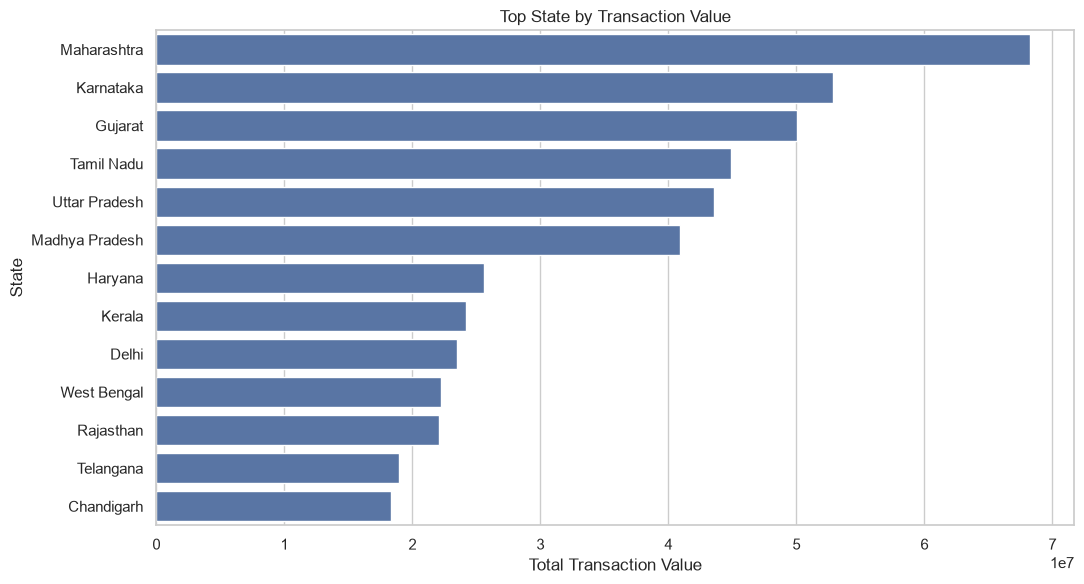

In [19]:
# ============================================================
# 19. GEOGRAPHIC ANALYSIS
# ============================================================

geo_col = None
for candidate in ["state", "city", "region", "location"]:
    if candidate in financial_analysis.columns:
        geo_col = candidate
        break

if geo_col:
    geo_summary = (
        financial_analysis.groupby(geo_col, dropna=False)
        .agg(
            customers=("customer_id", "nunique"),
            transactions=(geo_col, "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean"),
            fraud_transactions=("fraud_flag_clean", "sum")
        )
        .reset_index()
        .sort_values("total_value", ascending=False)
    )

    display(geo_summary.head(20))

    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=geo_summary.head(15),
        y=geo_col,
        x="total_value"
    )
    plt.title(f"Top {geo_col.title()} by Transaction Value")
    plt.xlabel("Total Transaction Value")
    plt.ylabel(geo_col.title())
    plt.tight_layout()
    plt.show()


## 20. Monthly trend analysis

,transaction_date,transactions,total_value,average_value,fraud_transactions,month
0,2023-01,1280,"11,366,473.37","8,880.06",14,2023-01
1,2023-02,1133,"10,408,639.87","9,186.80",13,2023-02
2,2023-03,1222,"11,140,911.26","9,116.95",15,2023-03
3,2023-04,1274,"11,593,929.41","9,100.42",14,2023-04
4,2023-05,1307,"11,914,631.46","9,116.01",16,2023-05
5,2023-06,1211,"10,898,637.36","8,999.70",17,2023-06
6,2023-07,1280,"12,024,699.42","9,394.30",14,2023-07
7,2023-08,1260,"11,136,338.27","8,838.36",20,2023-08
8,2023-09,1248,"11,208,135.38","8,980.88",20,2023-09
9,2023-10,1239,"11,080,452.74","8,943.06",18,2023-10


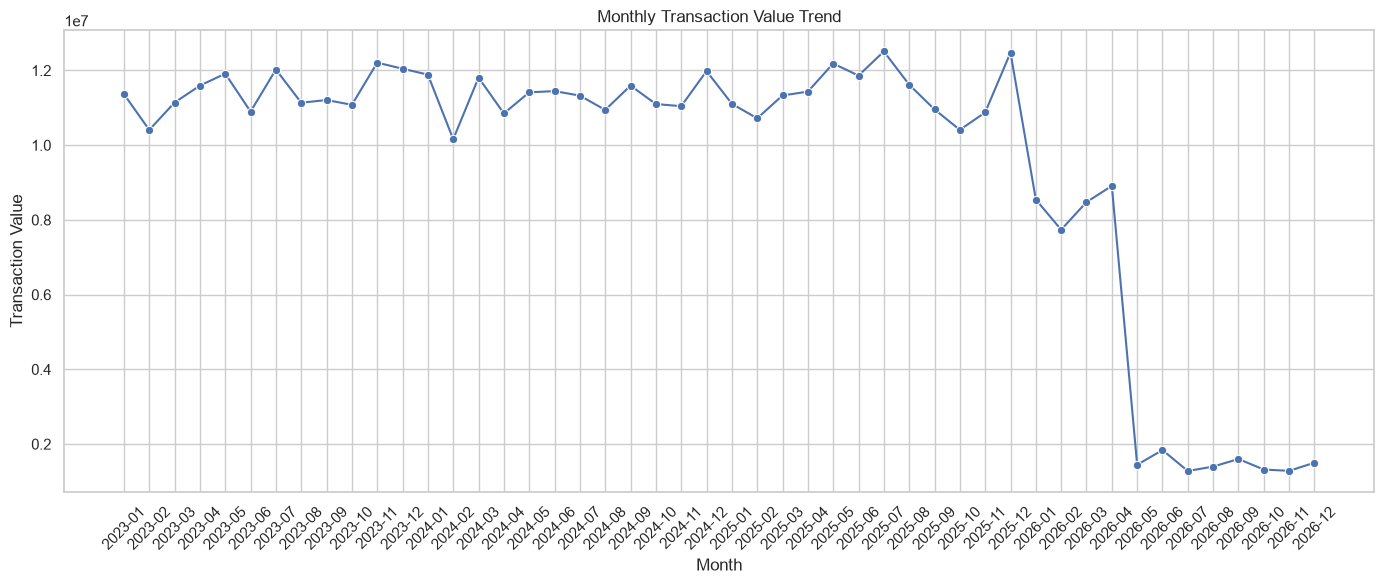

In [20]:
# ============================================================
# 20. MONTHLY TREND
# ============================================================

if transaction_date_col:
    monthly_summary = (
        financial_analysis
        .dropna(subset=[transaction_date_col])
        .groupby(financial_analysis[transaction_date_col].dt.to_period("M"))
        .agg(
            transactions=("amount", "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean"),
            fraud_transactions=("fraud_flag_clean", "sum")
        )
        .reset_index()
    )

    monthly_summary["month"] = monthly_summary[transaction_date_col].astype(str)

    display(monthly_summary)

    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=monthly_summary,
        x="month",
        y="total_value",
        marker="o"
    )
    plt.title("Monthly Transaction Value Trend")
    plt.xlabel("Month")
    plt.ylabel("Transaction Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 21. Transaction status / success analysis

,transaction_status,transactions,total_value,average_value,transaction_share_pct
2,Success,42870,"388,881,928.39","9,071.19",85.74
0,Failed,5096,"47,455,992.16","9,312.40",10.19
1,Pending,2035,"19,057,457.94","9,364.84",4.07


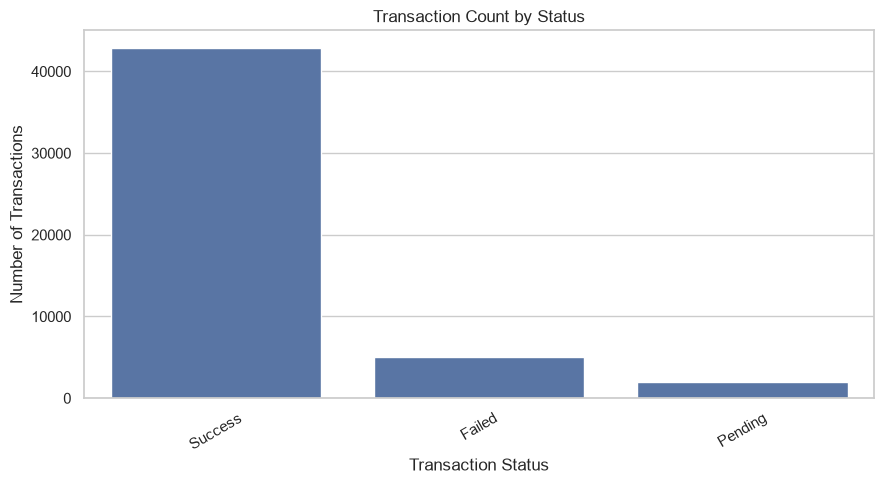

In [21]:
# ============================================================
# 21. STATUS ANALYSIS
# ============================================================

if "transaction_status" in financial_analysis.columns:
    status_summary = (
        financial_analysis.groupby("transaction_status", dropna=False)
        .agg(
            transactions=("transaction_status", "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean")
        )
        .reset_index()
        .sort_values("transactions", ascending=False)
    )

    status_summary["transaction_share_pct"] = (
        status_summary["transactions"] / status_summary["transactions"].sum() * 100
    )

    display(status_summary)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=status_summary, x="transaction_status", y="transactions")
    plt.title("Transaction Count by Status")
    plt.xlabel("Transaction Status")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 22. Risk score vs transaction value

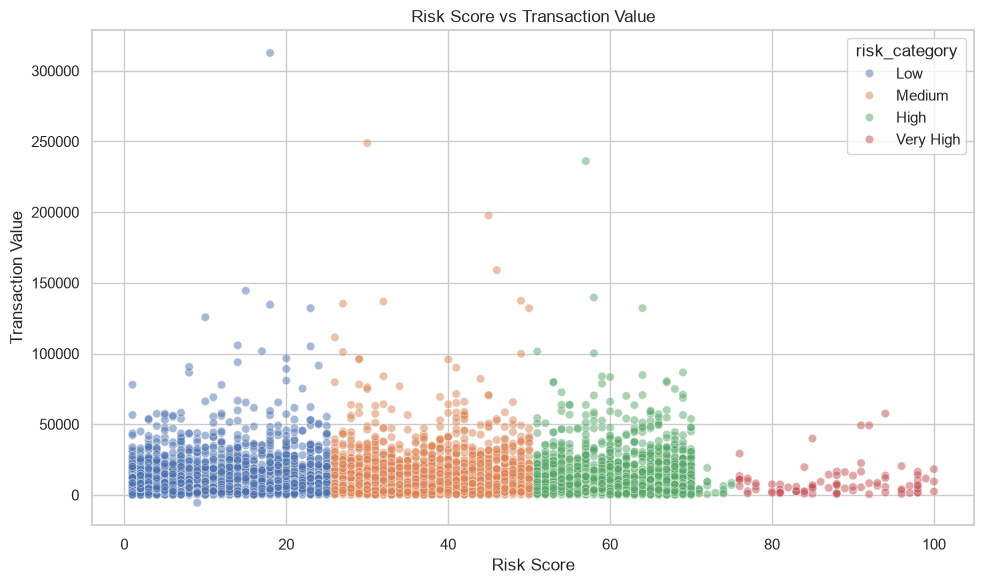

In [22]:
# ============================================================
# 22. RISK VS VALUE
# ============================================================

if {"risk_score", "amount"}.issubset(financial_analysis.columns):
    sample = financial_analysis.sample(
        min(10000, len(financial_analysis)),
        random_state=42
    )

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=sample,
        x="risk_score",
        y="amount",
        hue="risk_category" if "risk_category" in sample.columns else None,
        alpha=0.5
    )
    plt.title("Risk Score vs Transaction Value")
    plt.xlabel("Risk Score")
    plt.ylabel("Transaction Value")
    plt.tight_layout()
    plt.show()


## 23. Age and demographic analysis

,age_group,customers,transactions,total_value,average_value
0,<=18,37,104,"811,273.58","7,800.71"
1,19-25,365,3614,"33,526,311.49","9,276.79"
2,26-35,632,6145,"55,134,851.34","8,972.31"
3,36-45,706,6989,"62,787,515.47","8,983.76"
4,46-55,648,6253,"57,747,631.72","9,235.19"
5,56-65,500,5265,"47,760,950.83","9,071.41"
6,66+,16,20,"131,867.06","6,593.35"


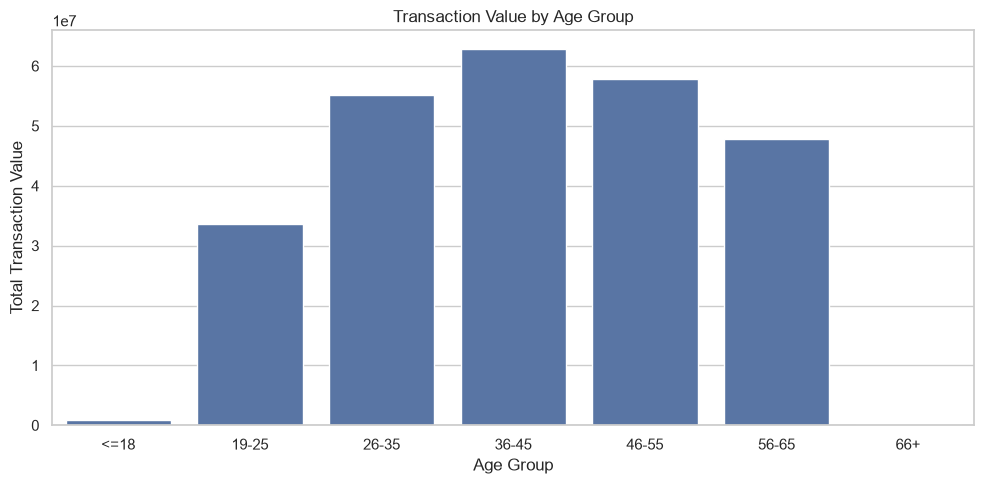

In [23]:
# ============================================================
# 23. AGE / DEMOGRAPHIC ANALYSIS
# ============================================================

if "age_group" in financial_analysis.columns:
    age_summary = (
        financial_analysis.groupby("age_group", observed=False)
        .agg(
            customers=("customer_id", "nunique"),
            transactions=("age_group", "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean")
        )
        .reset_index()
    )

    display(age_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=age_summary, x="age_group", y="total_value")
    plt.title("Transaction Value by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Total Transaction Value")
    plt.tight_layout()
    plt.show()


## 24. Outlier analysis

Outlier transactions: 3913
Outlier transaction value: 160859794.34


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no,first_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date,transaction_year,transaction_month,transaction_month_name,transaction_quarter,age,age_group,transaction_value,success_flag,fee_clean,tax_clean,total_charges,net_transaction_value,risk_category,income_segment,fraud_flag_clean,amount_outlier_flag
49677,T00049677,2025-08-21,A000762,C00251,Transfer,POS,Education,"312,586.25",0.00,0.00,INR,Success,No,18,REF6017737858,Arjun,Bansal,Female,6/11/1999,Mumbai,Maharashtra,Self Employed,Retail,"777,856.77",22-12-2018,2025,8,August,2025Q3,NaN,NaN,"312,586.25",1,0,0,0,"312,586.25",Low,Upper-Middle Income,False,True
14326,T00014326,2026-06-03,A002511,C00086,Transfer,Branch,Insurance,"248,865.05",497.73,89.59,INR,Success,No,30,REF3119534641,Pari,Verma,Female,10/10/1982,Nagpur,Maharashtra,Business Owner,Wealth,"1,630,489.11",31-07-2020,2026,6,June,2026Q2,NaN,NaN,"248,865.05",1,0,0,0,"248,865.05",Medium,High Income,False,True
29189,T00029189,2023-05-18,A003361,C03273,Deposit,Auto Debit,Entertainment,"246,429.91",0.00,0.00,INR,Failed,No,25,REF9940057526,Aarav,Mishra,Male,10/3/1963,Gurugram,Haryana,Freelancer,Retail,"245,073.82",7/10/2020,2023,5,May,2023Q2,NaN,NaN,"246,429.91",0,0,0,0,"246,429.91",Low,Low Income,False,True
25259,T00025259,2024-04-25,A002643,C03734,Loan EMI,Net Banking,Shopping,"236,089.81",472.18,84.99,INR,Success,No,57,REF8179983143,Krishna,Gupta,Female,6/5/1998,Mumbai,Maharashtra,Freelancer,Retail,"1,040,515.38",13-09-2023,2024,4,April,2024Q2,NaN,NaN,"236,089.81",1,0,0,0,"236,089.81",High,High Income,False,True
9884,T00009884,2025-08-24,A007331,C04303,Loan EMI,UPI,Rent,"202,872.21",0.00,0.00,INR,Pending,No,37,REF7534214924,Arjun,Bansal,Male,21-07-1964,Ahmedabad,Gujarat,Salaried,Retail,"2,006,664.69",26-10-2021,2025,8,August,2025Q3,61.00,56-65,"202,872.21",0,0,0,0,"202,872.21",Medium,High Income,False,True
25873,T00025873,2025-11-15,A001622,C00373,Transfer,Auto Debit,Utilities,"197,655.90",197.66,35.58,INR,Success,No,45,REF4744305339,Krishna,Desai,Male,8/6/1960,Gurugram,Haryana,Freelancer,Corporate,"1,699,624.89",20-09-2021,2025,11,November,2025Q4,NaN,NaN,"197,655.90",1,0,0,0,"197,655.90",Medium,High Income,False,True
8130,T00008130,2023-12-19,A005839,C04891,Transfer,Mobile App,Salary,"194,784.97",0.00,0.00,inr,Success,No,70,REF6142588225,Rohan,Chopra,Female,16-02-1984,Ahmedabad,Gujarat,Student,Retail,"548,063.24",27-06-2021,2023,12,December,2023Q4,39.00,36-45,"194,784.97",1,0,0,0,"194,784.97",High,Lower-Middle Income,False,True
34066,T00034066,2023-07-02,A007897,C00904,Investment,Mobile App,Salary,"191,736.51",383.47,69.02,INR,Success,No,20,REF1797642238,Neha,Malhotra,Male,4/10/2000,Jaipur,Rajasthan,Retired,Retail,"588,534.29",27-03-2022,2023,7,July,2023Q3,NaN,NaN,"191,736.51",1,0,0,0,"191,736.51",Low,Upper-Middle Income,False,True
29135,T00029135,2024-12-20,A007203,C04073,Investment,UPI,Travel,"189,469.82",947.35,170.52,INR,Success,No,58,REF9622191465,Aarav,Sharma,Female,17-04-1990,Coimbatore,Tamil Nadu,Student,Premium,"341,231.45",22-04-2019,2024,12,December,2024Q4,34.00,26-35,"189,469.82",1,0,0,0,"189,469.82",High,Low Income,False,True
43971,T00043971,2023-02-13,A004653,C04026,Deposit,UPI,Salary,"188,718.35",188.72,33.97,INR,Success,No,57,REF7257852127,Amit,Desai,Male,28-02-1994,Mysuru,Karnataka,Retired,SME,"1,111,095.58",20-04-2020,2023,2,February,2023Q1,28.00,26-35,"188,718.35",1,0,0,0,"188,718.35",High,High Income,False,True


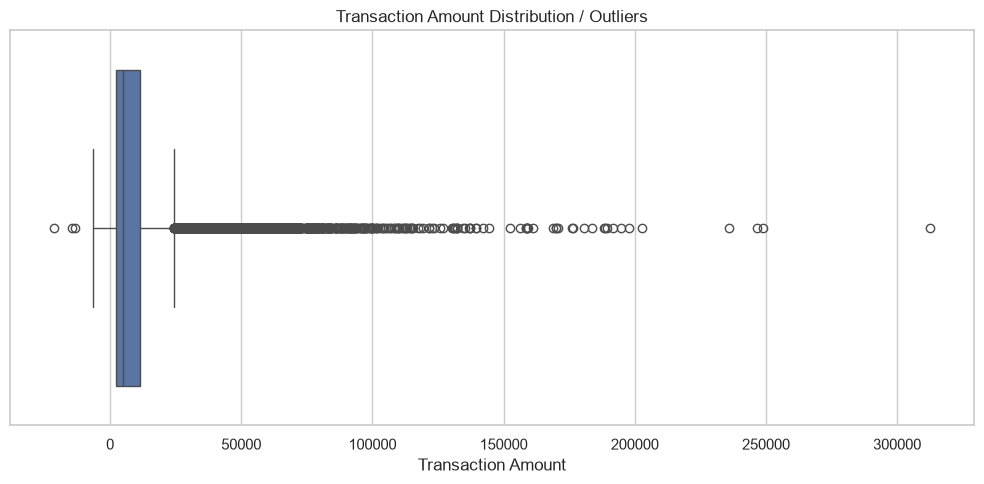

In [24]:
# ============================================================
# 24. OUTLIER ANALYSIS
# ============================================================

if "amount" in financial_analysis.columns:
    outlier_count = financial_analysis["amount_outlier_flag"].sum()
    outlier_value = financial_analysis.loc[
        financial_analysis["amount_outlier_flag"], "amount"
    ].sum()

    print("Outlier transactions:", outlier_count)
    print("Outlier transaction value:", outlier_value)

    display(
        financial_analysis.loc[
            financial_analysis["amount_outlier_flag"]
        ].sort_values("amount", ascending=False).head(20)
    )

    plt.figure(figsize=(10, 5))
    sns.boxplot(x=financial_analysis["amount"])
    plt.title("Transaction Amount Distribution / Outliers")
    plt.xlabel("Transaction Amount")
    plt.tight_layout()
    plt.show()


## 25. Yearly performance

In [25]:
# ============================================================
# 25. YEARLY PERFORMANCE
# ============================================================

if "transaction_year" in financial_analysis.columns:
    yearly_summary = (
        financial_analysis.groupby("transaction_year", dropna=False)
        .agg(
            transactions=("amount", "size"),
            total_value=("amount", "sum"),
            average_value=("amount", "mean"),
            fraud_transactions=("fraud_flag_clean", "sum")
        )
        .reset_index()
    )

    yearly_summary["success_rate_pct"] = (
        financial_analysis.groupby("transaction_year")["success_flag"].mean().values * 100
        if "success_flag" in financial_analysis.columns else np.nan
    )

    display(yearly_summary)


,transaction_year,transactions,total_value,average_value,fraud_transactions,success_rate_pct
0,2023,15034,"137,028,376.19","9,114.57",184,85.72
1,2024,15030,"135,557,059.79","9,019.10",187,85.48
2,2025,14944,"137,485,828.74","9,200.07",195,85.85
3,2026,4993,"45,324,113.77","9,077.53",64,86.26


## 26. Business insights

In [26]:
# ============================================================
# 26. BUSINESS INSIGHTS
# ============================================================

print("BUSINESS INSIGHTS")
print("=" * 80)

print(f"1. The dataset contains {total_customers:,.0f} unique customers and "
      f"{total_transactions:,.0f} integrated transactions.")

if pd.notna(total_value):
    print(f"2. Total transaction value is approximately ₹{total_value/1e7:,.2f} Cr, "
          f"with an average transaction value of ₹{average_transaction_value:,.2f}.")

if pd.notna(success_rate):
    print(f"3. Overall transaction success rate is {success_rate:,.2f}%. "
          f"Failed/non-success transactions should be monitored for operational improvement.")

print(f"4. {fraud_transactions:,.0f} transactions are flagged as fraud, "
      f"representing {fraud_transactions/total_transactions*100:,.2f}% of transactions.")

if pd.notna(fraud_amount):
    print(f"5. Fraud-flagged transaction value is approximately ₹{fraud_amount/1e5:,.2f} L.")

if pd.notna(average_risk_score):
    print(f"6. Average risk score is {average_risk_score:,.2f}. "
          f"Risk categories can be used to prioritize monitoring and review.")

if "channel" in financial_analysis.columns:
    top_channel = channel_summary.iloc[0]["channel"]
    print(f"7. {top_channel} is the highest-value transaction channel based on the analyzed data.")

if segment_col:
    top_segment = segment_summary.iloc[0][segment_col]
    print(f"8. {top_segment} is the leading customer segment by transaction value.")

print("9. Geographic, channel, merchant, risk, and customer-segment breakdowns can support targeted business actions.")
print("10. Fraud should be monitored using transaction count, amount, rate, channel, category, and trend.")


BUSINESS INSIGHTS
1. The dataset contains 3,983 unique customers and 50,001 integrated transactions.
2. Total transaction value is approximately ₹45.54 Cr, with an average transaction value of ₹9,107.73.
3. Overall transaction success rate is 85.74%. Failed/non-success transactions should be monitored for operational improvement.
4. 630 transactions are flagged as fraud, representing 1.26% of transactions.
5. Fraud-flagged transaction value is approximately ₹59.69 L.
6. Average risk score is 36.08. Risk categories can be used to prioritize monitoring and review.
7. UPI is the highest-value transaction channel based on the analyzed data.
8. Retail is the leading customer segment by transaction value.
9. Geographic, channel, merchant, risk, and customer-segment breakdowns can support targeted business actions.
10. Fraud should be monitored using transaction count, amount, rate, channel, category, and trend.


## 27. Recommended business actions

In [27]:
# ============================================================
# 27. RECOMMENDED ACTIONS
# ============================================================

recommendations = [
    ("Operations", "Investigate failed and non-success transactions to identify recurring operational issues."),
    ("Fraud", "Monitor fraud count, fraud amount, fraud rate, and high-risk channels/categories."),
    ("Risk", "Prioritize High and Very High risk transactions for additional review."),
    ("Customer", "Use customer segments to identify high-value groups and tailor engagement strategies."),
    ("Channels", "Compare transaction value, success rate, average value, and fraud rate by channel."),
    ("Geography", "Use geographic analysis for regional performance monitoring and drill-down."),
    ("Data Quality", "Validate duplicate transaction IDs, missing fees, negative amounts, and future-dated records before reporting."),
    ("Dashboard", "Use the final integrated dataset as the single source for Power BI reporting.")
]

recommendations_df = pd.DataFrame(recommendations, columns=["Area", "Recommended Action"])
display(recommendations_df)


,Area,Recommended Action
0,Operations,Investigate failed and non-success transaction...
1,Fraud,"Monitor fraud count, fraud amount, fraud rate,..."
2,Risk,Prioritize High and Very High risk transaction...
3,Customer,Use customer segments to identify high-value g...
4,Channels,"Compare transaction value, success rate, avera..."
5,Geography,Use geographic analysis for regional performan...
6,Data Quality,"Validate duplicate transaction IDs, missing fe..."
7,Dashboard,Use the final integrated dataset as the single...


## 28. Dashboard-ready KPI cards and filters

In [28]:
# ============================================================
# 28. POWER BI / DASHBOARD DESIGN GUIDE
# ============================================================

dashboard_kpis = [
    "Total Customers",
    "Total Transactions",
    "Total Transaction Value",
    "Average Transaction Value",
    "Success Rate",
    "Total Charges",
    "Fraud Transactions",
    "Fraud Amount",
    "High + Very High Risk Value"
]

dashboard_filters = [
    "Transaction Date",
    "Transaction Year",
    "Transaction Type",
    "Transaction Status",
    "Channel",
    "Customer Segment",
    "State / Region",
    "Merchant Category",
    "Risk Category",
    "Currency",
    "Fraud Flag"
]

print("Recommended KPI Cards:")
for x in dashboard_kpis:
    print("-", x)

print("\nRecommended Filters:")
for x in dashboard_filters:
    print("-", x)


Recommended KPI Cards:
- Total Customers
- Total Transactions
- Total Transaction Value
- Average Transaction Value
- Success Rate
- Total Charges
- Fraud Transactions
- Fraud Amount
- High + Very High Risk Value

Recommended Filters:
- Transaction Date
- Transaction Year
- Transaction Type
- Transaction Status
- Channel
- Customer Segment
- State / Region
- Merchant Category
- Risk Category
- Currency
- Fraud Flag


## 29. Important reporting cutoff check

In [29]:
# ============================================================
# 29. REPORTING CUTOFF CHECK
# ============================================================

REPORTING_CUTOFF = pd.Timestamp("2026-10-07")

if transaction_date_col:
    future_records = financial_analysis[
        financial_analysis[transaction_date_col] > REPORTING_CUTOFF
    ]

    print("Reporting cutoff:", REPORTING_CUTOFF.date())
    print("Records after reporting cutoff:", len(future_records))

    if len(future_records) > 0:
        print("WARNING: Future-dated records exist beyond the reporting cutoff.")
        display(
            future_records[
                [transaction_date_col, "customer_id", "amount"]
            ].head(20)
        )
    else:
        print("No records found after the reporting cutoff.")


Reporting cutoff: 2026-10-07
Records after reporting cutoff: 326


,transaction_date,customer_id,amount
265,2026-11-02,C04909,"13,738.57"
327,2026-12-03,C04966,"15,531.55"
638,2026-11-04,C04639,"1,615.91"
760,2026-11-02,C03253,"6,393.89"
935,2026-11-01,C03251,"2,550.77"
1063,2026-12-01,C04966,"2,622.37"
1405,2026-11-03,C04625,"4,447.31"
1474,2026-11-04,C02692,412.01
1492,2026-11-02,C04155,"4,802.62"
1523,2026-12-01,C02581,"4,297.82"


## 30. Final integrated dataset validation

In [30]:
# ============================================================
# 30. FINAL DATASET VALIDATION
# ============================================================

print("FINAL DATASET VALIDATION")
print("=" * 80)

print("Rows:", len(financial_analysis))
print("Columns:", len(financial_analysis.columns))
print("Unique customers:", financial_analysis["customer_id"].nunique())

if "transaction_id" in financial_analysis.columns:
    print("Unique transaction IDs:", financial_analysis["transaction_id"].nunique())

print("Duplicate rows:", financial_analysis.duplicated().sum())
print("Total missing cells:", financial_analysis.isna().sum().sum())

display(financial_analysis.head())
display(financial_analysis.tail())


FINAL DATASET VALIDATION
Rows: 50001
Columns: 41
Unique customers: 3983
Unique transaction IDs: 50000
Duplicate rows: 0
Total missing cells: 43246


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no,first_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date,transaction_year,transaction_month,transaction_month_name,transaction_quarter,age,age_group,transaction_value,success_flag,fee_clean,tax_clean,total_charges,net_transaction_value,risk_category,income_segment,fraud_flag_clean,amount_outlier_flag
0,T00000001,2025-02-21,A001795,C00629,Investment,Mobile App,Food Delivery,"24,721.24",123.61,22.25,INR,Success,No,63,REF8835851139,Neha,Desai,Female,16-07-1994,Coimbatore,Tamil Nadu,Salaried,Premium,"1,521,243.86",28-03-2025,2025,2,February,2025Q1,30.00,26-35,"24,721.24",1,0,0,0,"24,721.24",High,High Income,False,True
1,T00000002,2023-01-28,A004859,C02038,Transfer,UPI,Groceries,"18,711.77",93.56,16.84,INR,Success,No,21,REF9409811139,Aarav,Chopra,Female,18-12-1989,Bengaluru,Karnataka,Freelancer,Retail,"365,023.04",15-01-2021,2023,1,January,2023Q1,33.00,26-35,"18,711.77",1,0,0,0,"18,711.77",Low,Low Income,False,False
2,T00000003,2024-06-25,A003081,C00652,Transfer,Net Banking,Groceries,"45,865.90",0.00,0.00,INR,Success,No,25,REF1704628312,Sneha,Verma,Male,24-06-1988,Chandigarh,Chandigarh,Retired,Wealth,"1,973,706.42",2/10/2024,2024,6,June,2024Q2,36.00,36-45,"45,865.90",1,0,0,0,"45,865.90",Low,High Income,False,True
3,T00000004,2025-02-20,A004122,C01357,Withdrawal,Auto Debit,Salary,"4,310.91",NaN,0.78,INR,Failed,No,43,REF3937614748,Pooja,Reddy,Male,24-09-2002,Pune,Maharashtra,Self Employed,Corporate,"555,476.53",15-03-2020,2025,2,February,2025Q1,22.00,19-25,"4,310.91",0,0,0,0,"4,310.91",Medium,Lower-Middle Income,False,False
4,T00000005,2024-06-08,A004150,C02547,Deposit,Branch,Shopping,"11,646.45",0.00,0.00,INR,Success,No,5,REF5855288886,Reyansh,Chopra,Female,22-09-2004,Mysuru,Karnataka,Self Employed,SME,"1,107,795.82",25-09-2023,2024,6,June,2024Q2,19.00,19-25,"11,646.45",1,0,0,0,"11,646.45",Low,High Income,False,False


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no,first_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date,transaction_year,transaction_month,transaction_month_name,transaction_quarter,age,age_group,transaction_value,success_flag,fee_clean,tax_clean,total_charges,net_transaction_value,risk_category,income_segment,fraud_flag_clean,amount_outlier_flag
49996,T00049996,2024-12-16,A006276,C04522,Transfer,Auto Debit,Shopping,"7,413.11",14.83,2.67,INR,Success,No,15,REF8146545946,Karan,Iyer,Male,13-06-1985,Kolkata,West Bengal,Retired,Retail,"484,622.26",10/5/2024,2024,12,December,2024Q4,39.00,36-45,"7,413.11",1,0,0,0,"7,413.11",Low,Lower-Middle Income,False,False
49997,T00049997,2023-11-27,A002509,C04382,Fee Charge,Mobile App,Education,650.56,0.65,0.12,INR,Success,No,57,REF5933519324,Rahul,Patel,Male,2/12/1976,Gurugram,Haryana,Salaried,Premium,"324,000.00",9/5/2022,2023,11,November,2023Q4,NaN,NaN,650.56,1,0,0,0,650.56,High,Low Income,False,False
49998,T00049998,2024-01-11,A001430,C00687,Bill Payment,UPI,Travel,"1,295.05",0.00,0.00,INR,Success,No,51,REF7245867820,Ayaan,Gupta,Female,19-12-2002,Chennai,Tamil Nadu,Retired,Premium,"1,213,289.57",13-07-2024,2024,1,January,2024Q1,21.00,19-25,"1,295.05",1,0,0,0,"1,295.05",High,High Income,False,False
49999,T00049999,2025-05-23,A006962,C04793,Deposit,Mobile App,Insurance,"8,397.34",41.99,7.56,INR,Failed,No,48,REF3169960745,Myra,Sharma,Female,21-04-1970,Jaipur,Rajasthan,Freelancer,SME,"1,338,127.38",27-04-2022,2025,5,May,2025Q2,55.00,46-55,"8,397.34",0,0,0,0,"8,397.34",Medium,High Income,False,False
50000,T00050000,2024-09-25,A004944,C00319,Deposit,Branch,Bank Charges,"-4,962.93",9.93,1.79,INR,Success,No,8,REF4722178841,Sara,Joshi,Male,28-08-1978,Nagpur,Maharashtra,Freelancer,Retail,"540,236.17",13-04-2022,2024,9,September,2024Q3,46.00,46-55,"-4,962.93",1,0,0,0,"-4,962.93",Low,Lower-Middle Income,False,False


## 31. Export ONE final cleaned dataset

In [31]:
# ============================================================
# 31. EXPORT ONE FINAL CLEANED DATASET
# ============================================================

financial_analysis.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Final cleaned dataset exported successfully:")
print(OUTPUT_FILE)

print("\nExported shape:", financial_analysis.shape)

# Verify exported file
verified = pd.read_csv(OUTPUT_FILE)

print("Verified exported rows:", len(verified))
print("Verified exported columns:", len(verified.columns))
print("File exists:", os.path.exists(OUTPUT_FILE))


Final cleaned dataset exported successfully:
C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis\financial_analysis_cleaned.csv

Exported shape: (50001, 41)
Verified exported rows: 50001
Verified exported columns: 41
File exists: True


# 32. Final project conclusion

### Final analytical story

The project integrates customer and financial transaction data into a single analysis-ready dataset. The workflow covers data quality, transaction performance, customer behavior, channel performance, risk, fraud, geography, merchant/category behavior, trends, and outliers.

### Recommended dashboard story

1. **Executive Overview** — customers, transactions, value, success rate, charges, fraud and risk.
2. **Transaction Performance** — transaction type, status, channel and monthly trends.
3. **Customer Analysis** — customer segments, demographics and high-value behavior.
4. **Risk & Fraud** — risk categories, fraud rate, fraud amount, high-risk exposure and channel/category breakdown.
5. **Geographic / Merchant Analysis** — regional and category-level performance.
6. **Data Quality** — duplicates, missing values, invalid values and reporting-cutoff exceptions.

### Final deliverable

Only one cleaned master dataset is exported:

`financial_analysis_cleaned.csv`

This file is the recommended source for the Power BI dashboard.


In [32]:
# ============================================================
# CONNECT CLEANED DATASET TO MYSQL
# ============================================================

!pip install sqlalchemy pymysql -q

In [33]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# MySQL connection details
MYSQL_USER = "root"
MYSQL_PASSWORD = "12345678"
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DATABASE = "financial_db"

# Create connection
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{quote_plus(MYSQL_PASSWORD)}"
    f"@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

print("MySQL connection successful!")

MySQL connection successful!


In [34]:
# ============================================================
# LOAD CLEANED CSV
# ============================================================

cleaned_file = r"C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\Financial Analysis Dashboard\Python Analysis\financial_analysis_cleaned.csv"

df_cleaned = pd.read_csv(cleaned_file)

print("Rows:", len(df_cleaned))
print("Columns:", len(df_cleaned.columns))

display(df_cleaned.head())

Rows: 50001
Columns: 41


,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,currency,transaction_status,is_fraud,risk_score,reference_no,first_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date,transaction_year,transaction_month,transaction_month_name,transaction_quarter,age,age_group,transaction_value,success_flag,fee_clean,tax_clean,total_charges,net_transaction_value,risk_category,income_segment,fraud_flag_clean,amount_outlier_flag
0,T00000001,2025-02-21,A001795,C00629,Investment,Mobile App,Food Delivery,"24,721.24",123.61,22.25,INR,Success,No,63,REF8835851139,Neha,Desai,Female,16-07-1994,Coimbatore,Tamil Nadu,Salaried,Premium,"1,521,243.86",28-03-2025,2025,2,February,2025Q1,30.00,26-35,"24,721.24",1,0,0,0,"24,721.24",High,High Income,False,True
1,T00000002,2023-01-28,A004859,C02038,Transfer,UPI,Groceries,"18,711.77",93.56,16.84,INR,Success,No,21,REF9409811139,Aarav,Chopra,Female,18-12-1989,Bengaluru,Karnataka,Freelancer,Retail,"365,023.04",15-01-2021,2023,1,January,2023Q1,33.00,26-35,"18,711.77",1,0,0,0,"18,711.77",Low,Low Income,False,False
2,T00000003,2024-06-25,A003081,C00652,Transfer,Net Banking,Groceries,"45,865.90",0.00,0.00,INR,Success,No,25,REF1704628312,Sneha,Verma,Male,24-06-1988,Chandigarh,Chandigarh,Retired,Wealth,"1,973,706.42",2/10/2024,2024,6,June,2024Q2,36.00,36-45,"45,865.90",1,0,0,0,"45,865.90",Low,High Income,False,True
3,T00000004,2025-02-20,A004122,C01357,Withdrawal,Auto Debit,Salary,"4,310.91",NaN,0.78,INR,Failed,No,43,REF3937614748,Pooja,Reddy,Male,24-09-2002,Pune,Maharashtra,Self Employed,Corporate,"555,476.53",15-03-2020,2025,2,February,2025Q1,22.00,19-25,"4,310.91",0,0,0,0,"4,310.91",Medium,Lower-Middle Income,False,False
4,T00000005,2024-06-08,A004150,C02547,Deposit,Branch,Shopping,"11,646.45",0.00,0.00,INR,Success,No,5,REF5855288886,Reyansh,Chopra,Female,22-09-2004,Mysuru,Karnataka,Self Employed,SME,"1,107,795.82",25-09-2023,2024,6,June,2024Q2,19.00,19-25,"11,646.45",1,0,0,0,"11,646.45",Low,High Income,False,False


In [35]:
# ============================================================
# LOAD CLEANED DATA INTO MYSQL
# ============================================================

df_cleaned.to_sql(
    name="financial_transactions",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000,
    method="multi"
)

print("SUCCESS!")
print("Table created: financial_transactions")
print("Database: financial_db")
print("Rows loaded:", len(df_cleaned))

SUCCESS!
Table created: financial_transactions
Database: financial_db
Rows loaded: 50001


In [36]:
# Verify row count

with engine.connect() as conn:
    result = conn.exec_driver_sql(
        "SELECT COUNT(*) AS total_records "
        "FROM financial_transactions"
    )

    print("Records in MySQL:", result.scalar())

Records in MySQL: 50001
